# 📒 Notebook 2 — Data Preparation for Collaborative Filtering

**Source:** `DATAMINING.ANALYTICS.RESTAURANT_RECOMMENDATION_BASE` (4.7M rows)

**What this notebook does:**
1. Pulls 500k rows from Snowflake (sampled randomly)
2. Cleans & encodes USER_ID and BUSINESS_ID → integers (required by Surprise library)
3. Splits into 80% train / 20% test
4. Saves everything to disk so Notebooks 3 & 4 don't re-pull from Snowflake

**Output files saved locally:**
- `data/ratings_train.csv` — training set
- `data/ratings_test.csv` — test set  
- `data/user_encoder.pkl` — maps USER_ID string ↔ integer
- `data/business_encoder.pkl` — maps BUSINESS_ID string ↔ integer
- `data/business_meta.csv` — business metadata (name, city, state, stars, category)

## 1. Install Dependencies

In [28]:
!pip install snowflake-connector-python scikit-surprise pandas tqdm -q

## 2. Configuration

In [29]:
import os
os.makedirs("data", exist_ok=True)

SNOWFLAKE_CONFIG = {
    "user":      "DATAMINING",
    "password":  "Datamining@881",
    "account":   "VETPRKL-MI71367",
    "warehouse": "COMPUTE_WH",
    "database":  "DATAMINING",
    "schema":    "ANALYTICS"
}

SAMPLE_SIZE  = 4000000   # 500k rows from 4.7M
TEST_SIZE    = 0.20     # 20% held out for evaluation
RANDOM_STATE = 42

print("✅ Config ready")

✅ Config ready


## 3. Pull Data from Snowflake
We use `TABLESAMPLE` to get a random 500k sample efficiently — much faster than pulling all 4.7M rows.

In [30]:
import snowflake.connector
import pandas as pd

print("🔌 Connecting to Snowflake...")
conn = snowflake.connector.connect(**SNOWFLAKE_CONFIG)

# Pull the columns we need: user-business-rating triplet + business metadata
# query = f"""
#     SELECT
#         USER_ID,
#         BUSINESS_ID,
#         TARGET_RATING,
#         BUSINESS_NAME,
#         CITY,
#         STATE,
#         BUSINESS_AVG_STARS,
#         CATEGORIES
#     FROM DATAMINING.ANALYTICS.RESTAURANT_RECOMMENDATION_BASE
#     WHERE TARGET_RATING IS NOT NULL
#       AND USER_ID IS NOT NULL
#       AND BUSINESS_ID IS NOT NULL
#     ORDER BY RANDOM()
#     LIMIT {SAMPLE_SIZE}
# """

query = """
    SELECT
        USER_ID,
        BUSINESS_ID,
        TARGET_RATING,
        BUSINESS_NAME,
        CITY,
        STATE,
        BUSINESS_AVG_STARS,
        CATEGORIES
    FROM DATAMINING.ANALYTICS.RESTAURANT_RECOMMENDATION_BASE
    WHERE TARGET_RATING IS NOT NULL
      AND USER_ID IS NOT NULL
      AND BUSINESS_ID IS NOT NULL
"""

print(f"⏳ Pulling {SAMPLE_SIZE:,} rows (random sample)...")
df = pd.read_sql(query, conn)
conn.close()

df.columns = [c.lower() for c in df.columns]
print(f"✅ Fetched: {len(df):,} rows")
print(f"   Unique users     : {df['user_id'].nunique():,}")
print(f"   Unique businesses: {df['business_id'].nunique():,}")
print(f"   Rating range     : {df['target_rating'].min()} – {df['target_rating'].max()}")
df.head(3)

🔌 Connecting to Snowflake...
⏳ Pulling 4,000,000 rows (random sample)...


/var/folders/jh/2z6063n91jn5nsq56zvsxlhw0000gn/T/ipykernel_2301/3910321257.py:43: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


✅ Fetched: 4,724,684 rows
   Unique users     : 1,446,031
   Unique businesses: 52,286
   Rating range     : 1 – 5


,user_id,business_id,target_rating,business_name,city,state,business_avg_stars,categories
0,Q-qq0R1KygP0Ogf-wMjdeA,AccXb_D8EbTuOlSK5MBtew,1,The Ranch House Grill,Tampa,FL,3.5,"American (Traditional), Restaurants, Steakhous..."
1,Q-qq0R1KygP0Ogf-wMjdeA,gqmQA9TIdmKz3tCnz6DqFA,5,Yoko's,Tampa,FL,4.0,"Japanese, Restaurants, Sushi Bars"
2,yzswSbGR0rGWAM9QRUsWlg,aPD0HkuA7MXNhZZqXiGF4g,5,McCreary's Irish Pub and Eatery,Franklin,TN,3.5,"Pubs, Bars, Irish Pub, Irish, American (New), ..."


In [31]:
df_copy = df.copy()

## 4. Explore Ratings Distribution

=== Rating Distribution ===
target_rating
1     567227
2     404495
3     543126
4    1130305
5    2079531

Mean rating: 3.79


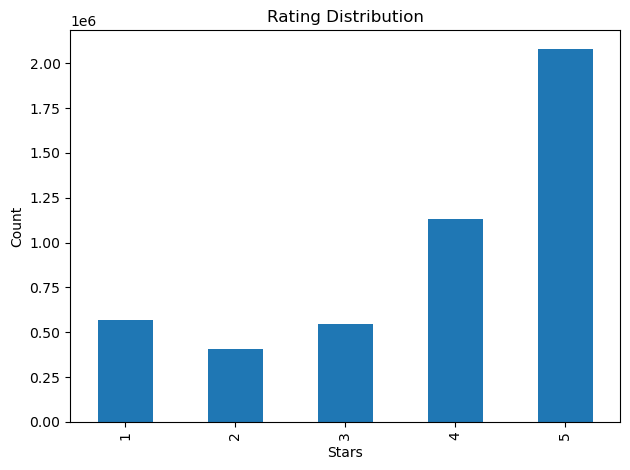

In [32]:
import matplotlib.pyplot as plt

print("=== Rating Distribution ===")
print(df["target_rating"].value_counts().sort_index().to_string())
print(f"\nMean rating: {df['target_rating'].mean():.2f}")

df["target_rating"].value_counts().sort_index().plot(
    kind="bar", title="Rating Distribution", xlabel="Stars", ylabel="Count"
)
plt.tight_layout()
plt.show()

## 5. Filter — Keep Only Users & Businesses with Enough Reviews
Users/businesses with fewer than 3 reviews are too sparse for collaborative filtering.
Removing them improves model quality significantly.

In [33]:
# MIN_USER_REVIEWS     = 3   # User must have rated at least 3 restaurants
# MIN_BUSINESS_REVIEWS = 3   # Business must have at least 3 ratings in sample

MIN_USER_REVIEWS = 10
MIN_BUSINESS_REVIEWS = 10

print(f"Before filtering: {len(df):,} rows")

# Filter users
user_counts = df["user_id"].value_counts()
valid_users = user_counts[user_counts >= MIN_USER_REVIEWS].index
df = df[df["user_id"].isin(valid_users)]

# Filter businesses
biz_counts = df["business_id"].value_counts()
valid_biz  = biz_counts[biz_counts >= MIN_BUSINESS_REVIEWS].index
df = df[df["business_id"].isin(valid_biz)]

df = df.reset_index(drop=True)
print(f"After filtering : {len(df):,} rows")
print(f"   Unique users     : {df['user_id'].nunique():,}")
print(f"   Unique businesses: {df['business_id'].nunique():,}")

Before filtering: 4,724,684 rows
After filtering : 1,974,927 rows
   Unique users     : 77,443
   Unique businesses: 33,016


## 6. Encode USER_ID & BUSINESS_ID → Integers
The Surprise library needs integer or string IDs (strings are fine, but we encode anyway
for consistency and to enable efficient lookup at inference time).

In [34]:
import pickle

# Build encoders: string ID → integer index, and reverse
unique_users = df["user_id"].unique()
unique_biz   = df["business_id"].unique()

user_encoder = {
    "str2idx": {uid: i for i, uid in enumerate(unique_users)},
    "idx2str": {i: uid for i, uid in enumerate(unique_users)}
}
biz_encoder = {
    "str2idx": {bid: i for i, bid in enumerate(unique_biz)},
    "idx2str": {i: bid for i, bid in enumerate(unique_biz)}
}

df["user_idx"] = df["user_id"].map(user_encoder["str2idx"])
df["biz_idx"]  = df["business_id"].map(biz_encoder["str2idx"])

# Save encoders
with open("data/user_encoder.pkl", "wb") as f:
    pickle.dump(user_encoder, f)
with open("data/business_encoder.pkl", "wb") as f:
    pickle.dump(biz_encoder, f)

print(f"✅ Encoders saved")
print(f"   Users    : {len(unique_users):,}")
print(f"   Businesses: {len(unique_biz):,}")

✅ Encoders saved
   Users    : 77,443
   Businesses: 33,016


## 7. Save Business Metadata
One row per business — used later to display recommendation results.

In [35]:
business_meta = (
    df[["business_id", "business_name", "city", "state", "business_avg_stars", "categories"]]
    .drop_duplicates(subset="business_id")
    .reset_index(drop=True)
)

business_meta.to_csv("data/business_meta.csv", index=False)
print(f"✅ Business metadata saved: {len(business_meta):,} unique restaurants")
business_meta.head(3)

✅ Business metadata saved: 33,016 unique restaurants


,business_id,business_name,city,state,business_avg_stars,categories
0,XSuO2E30ArnrjH9jquaK5Q,CALI - Tampa Palms,Tampa,FL,4.0,"Gluten-Free, American (New), Mexican, Pizza, B..."
1,QHWYlmVbLC3K6eglWoHVvA,Datz,Tampa,FL,4.0,"Burgers, Bars, Restaurants, American (Traditio..."
2,Vpv7_M6dpg92GwappohXlw,Rome + Fig,Tampa,FL,4.5,"Seafood, Restaurants, Chicken Wings, Breakfast..."


## 8. Train / Test Split

In [36]:
from sklearn.model_selection import train_test_split

# Keep only the columns Surprise needs: user, item, rating
ratings = df[["user_id", "business_id", "target_rating"]].copy()

train_df, test_df = train_test_split(
    ratings,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

train_df.to_csv("data/ratings_train.csv", index=False)
test_df.to_csv("data/ratings_test.csv",   index=False)

print(f"✅ Train: {len(train_df):,} rows  |  Test: {len(test_df):,} rows")
print(f"   Saved to data/ratings_train.csv and data/ratings_test.csv")

✅ Train: 1,579,941 rows  |  Test: 394,986 rows
   Saved to data/ratings_train.csv and data/ratings_test.csv


## 9. Summary

In [37]:
import os

print("=" * 50)
print("✅ DATA PREP COMPLETE")
print("=" * 50)
for fname in os.listdir("data"):
    fpath = os.path.join("data", fname)
    size_mb = os.path.getsize(fpath) / (1024 * 1024)
    print(f"   {fname:<30} {size_mb:.1f} MB")
print("\n▶ Next: Run Notebook 3 (SVD) and Notebook 4 (KNN)")

✅ DATA PREP COMPLETE
   ratings_train.csv              72.3 MB
   business_encoder.pkl           1.1 MB
   business_meta.csv              3.8 MB
   ratings_test.csv               18.1 MB
   user_encoder.pkl               2.7 MB

▶ Next: Run Notebook 3 (SVD) and Notebook 4 (KNN)
